# Exploratory Data Analysis Starter

## Import packages

In [184]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from mistune.plugins.abbr import render_abbr


# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---

## Loading data with Pandas

We need to load `client_data.csv` and `price_data.csv` into individual dataframes so that we can work with them in Python. For this notebook and all further notebooks, it will be assumed that the CSV files will the placed in the same file location as the notebook. If they are not, please adjust the directory within the `read_csv` method accordingly.

In [ ]:
client_df = pd.read_csv('../data/client_data.csv')
price_df = pd.read_csv('../data/price_data.csv')

You can view the first 3 rows of a dataframe using the `head` method. Similarly, if you wanted to see the last 3, you can use `tail(3)`

In [186]:
client_df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


In [187]:
price_df.head(3)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


---

## Descriptive statistics of data

### Data types

It is useful to first understand the data that you're dealing with along with the data types of each column. The data types may dictate how you transform and engineer features.

To get an overview of the data types within a data frame, use the `info()` method.

In [188]:
display(client_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

None

In [189]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


### Statistics

Now let's look at some statistics about the datasets. We can do this by using the `describe()` method.

In [190]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [191]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


---

## Data visualization

If you're working in Python, two of the most popular packages for visualization are `matplotlib` and `seaborn`. We highly recommend you use these, or at least be familiar with them because they are ubiquitous!

Below are some functions that you can use to get started with visualizations. 

In [192]:
def plot_stacked_bars(dataframe, title_, size_=(12, 5), rot_=0, legend_="upper right"):
    """
    Plot stacked bars with annotations
    """
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # Annotate bars
    annotate_stacked_bars(ax, textsize=10)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=10):
    """
    Add value annotations to the bars
    """

    # Iterate over the plotted rectanges/bars
    for p in ax.patches:
        
        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )

def plot_distribution(dataframe, column, ax, bins_=50, c_quantile = None):
    """
    Plot variable distirbution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data_prepare to be plot

    if c_quantile is not None:
        c = dataframe[column].quantile(c_quantile)
        dataframe = dataframe[dataframe[column] < c].reset_index(drop=True)

    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn"sh:dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

shThhe first function `plot_stacked_bars` is used to plot a stacked bar chart. An example of how you could use this is shown below:

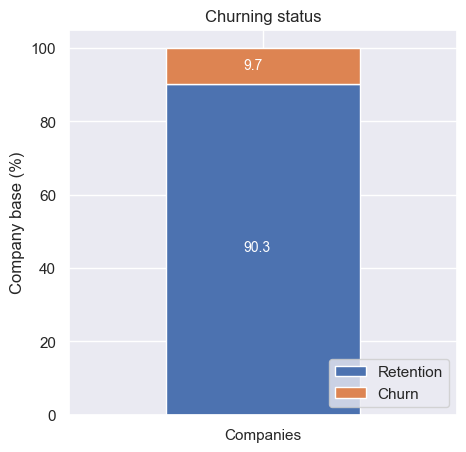

In [193]:
churn = client_df[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")

The second function `annotate_bars` is used by the first function, but the third function `plot_distribution` helps you to plot the distribution of a numeric column. An example of how it can be used is given below:

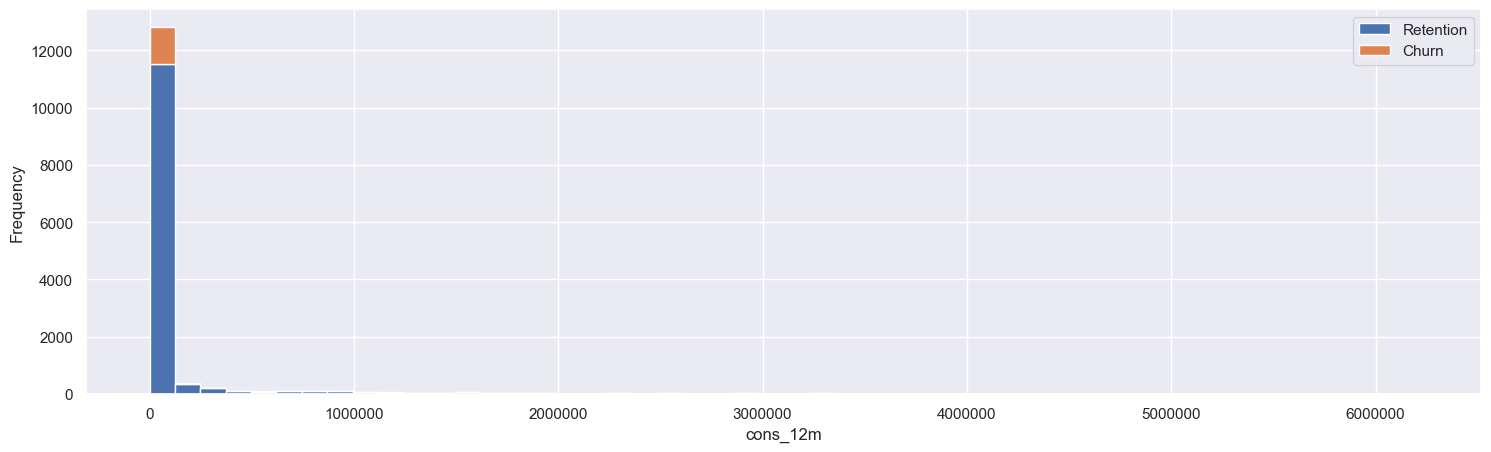

In [194]:
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

fig, axs = plt.subplots(nrows=1, figsize=(18, 5))

plot_distribution(consumption, 'cons_12m', axs)

In [195]:
def plot_stacked_relationship_factor_and_churn(column = ''):
    dataframe = client_df[['id','churn',column]]
    dataframe_table = dataframe.groupby([column,'churn'])['id'].count().unstack(level = 1).fillna(0)
        #be careful to assign column 'id' to count the number
    dataframe_table = dataframe_table.div(dataframe_table.sum(axis = 1), axis = 0) *100
    plot_stacked_bars(dataframe_table.sort_values(by = [1], ascending = False),f'relationship between {column} & churn',rot_=30)

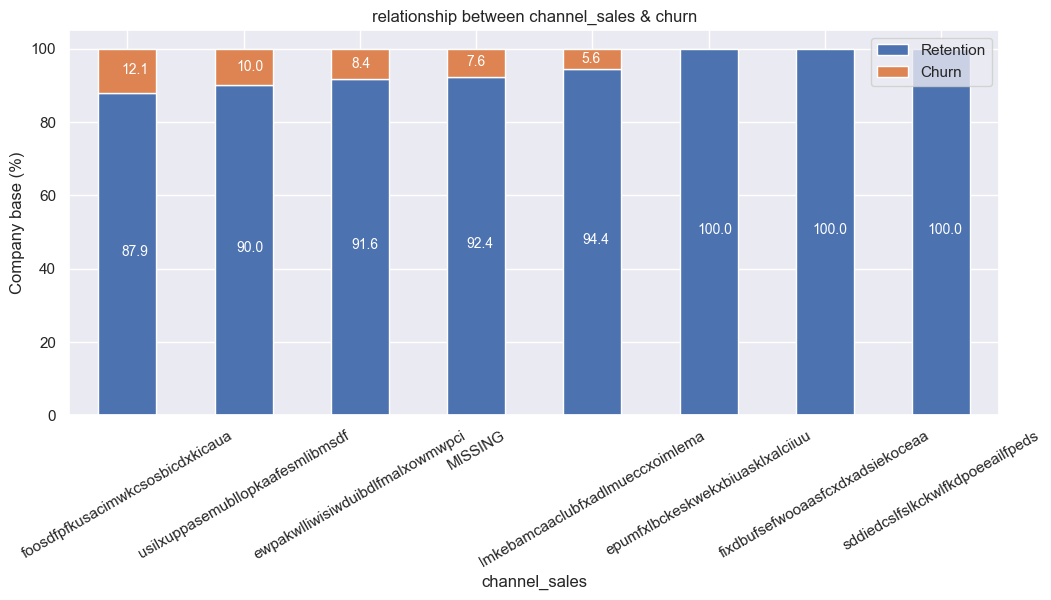

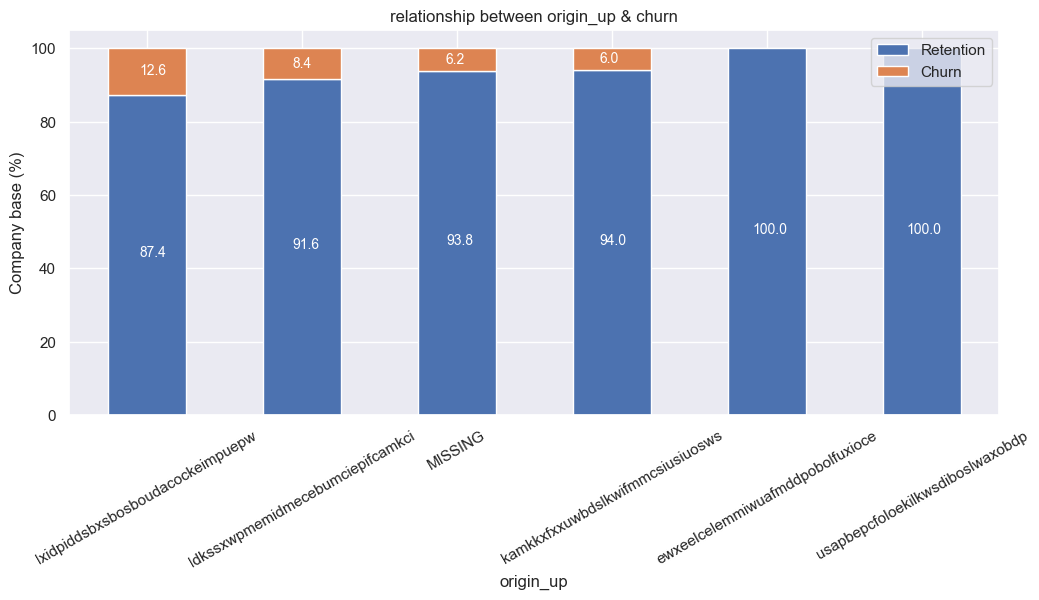

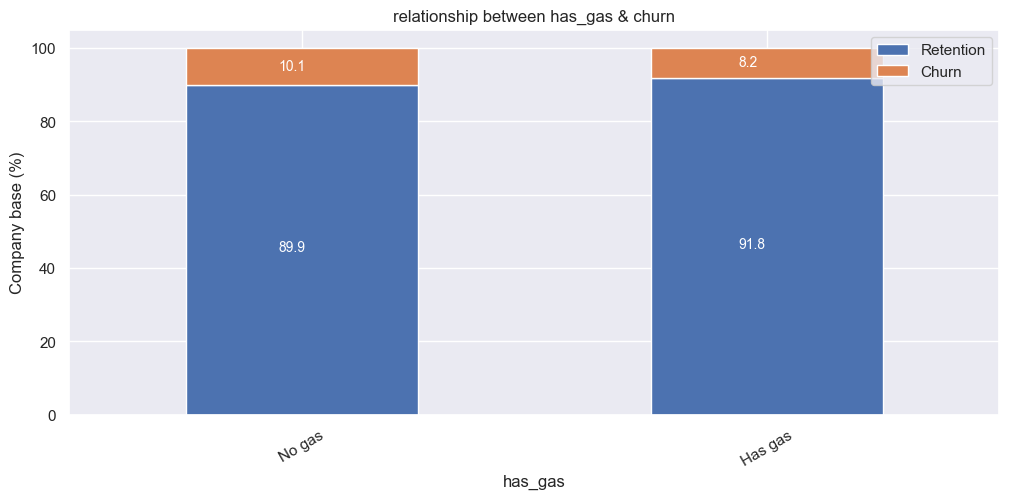

In [196]:
plot_stacked_relationship_factor_and_churn('channel_sales')

plot_stacked_relationship_factor_and_churn('origin_up')

gas_map = ({'t': 'Has gas', 'f': 'No gas'})
client_df['has_gas'] = client_df['has_gas'].map(gas_map,)
plot_stacked_relationship_factor_and_churn('has_gas')

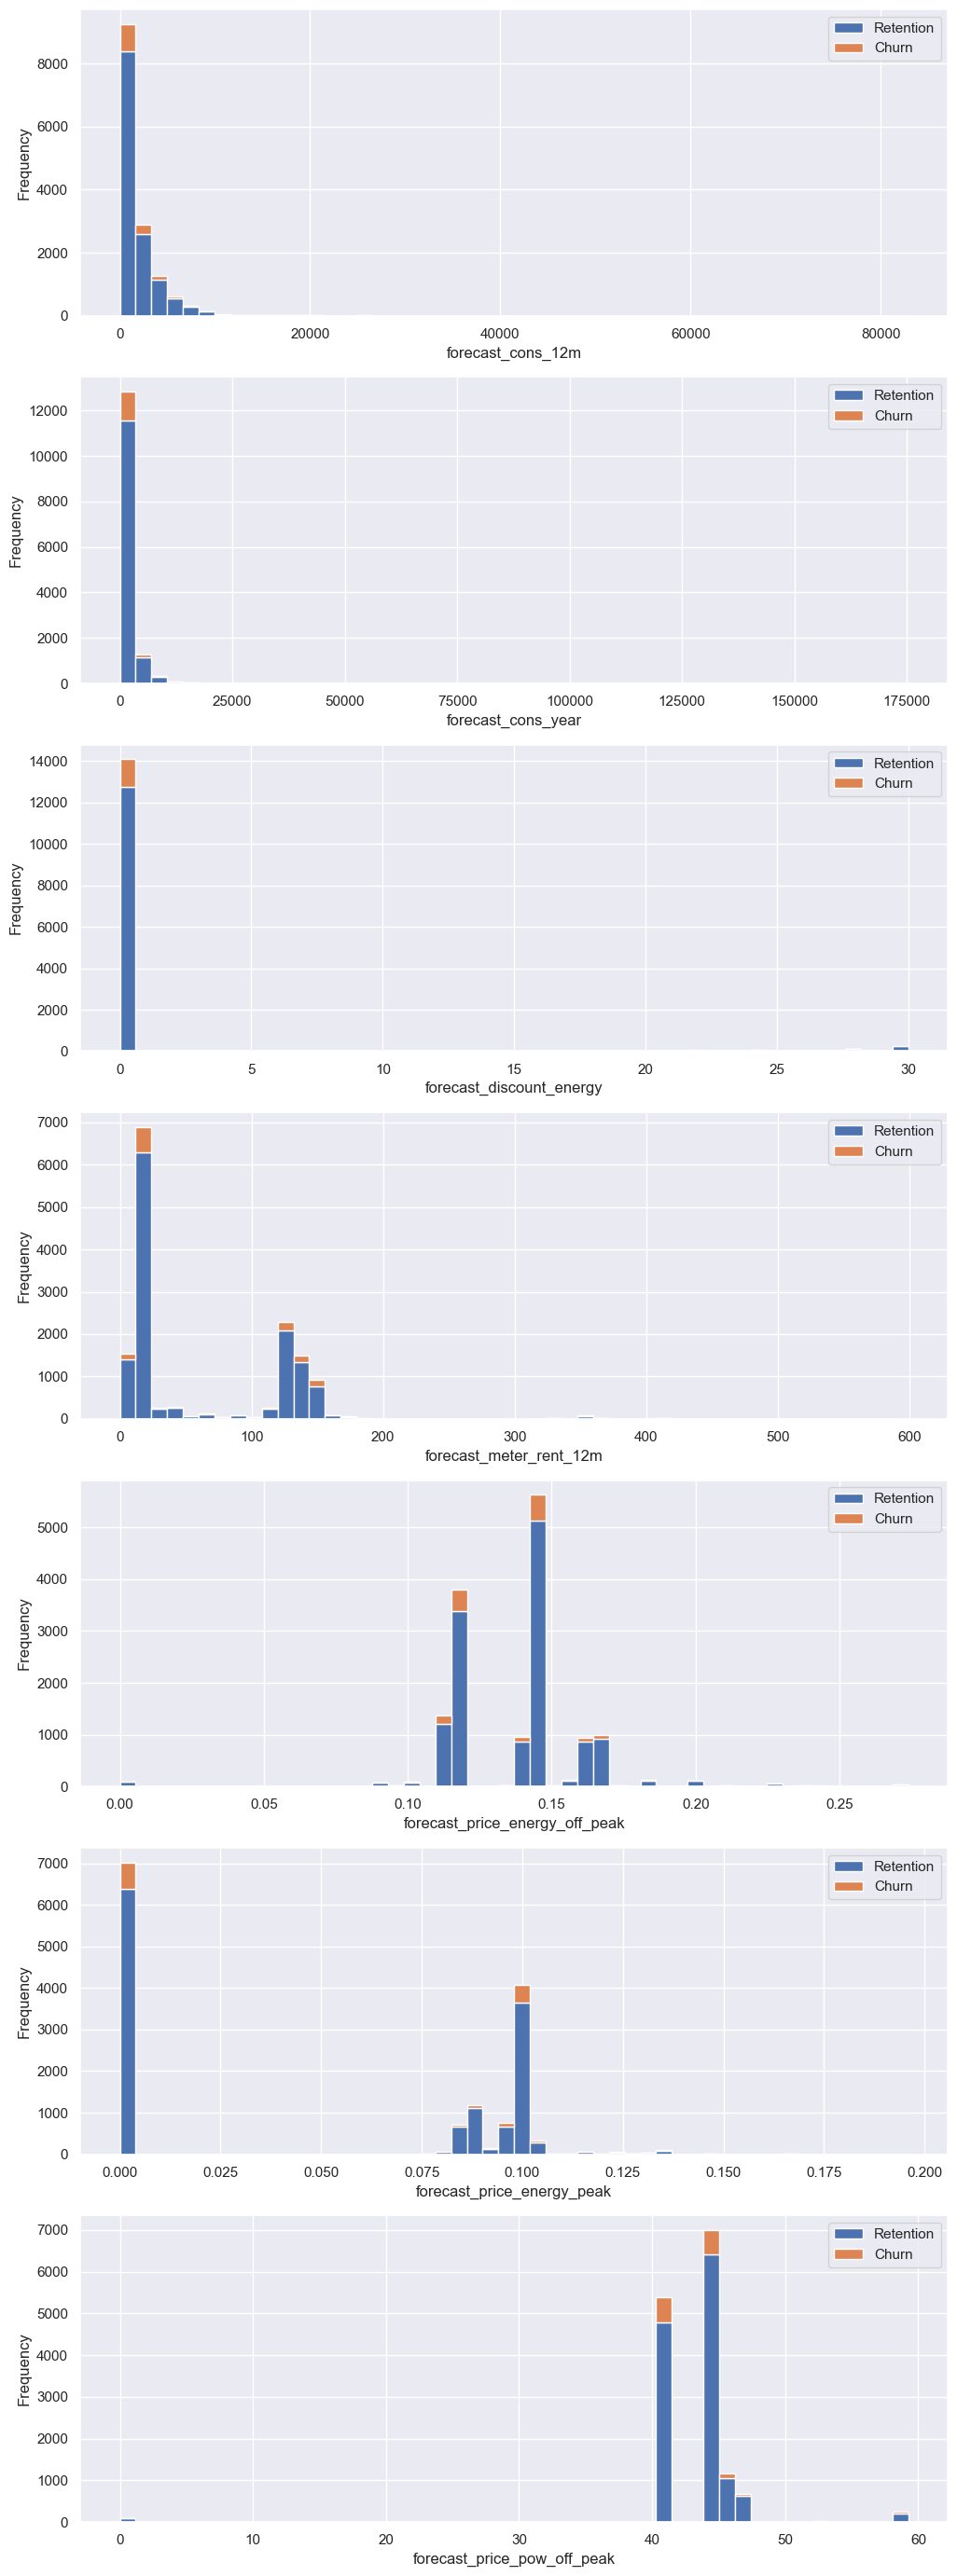

In [197]:
FORECAST = client_df.columns[9:16].tolist()
forecast_data = client_df[['id', 'churn'] + FORECAST]

fig, axs = plt.subplots(nrows=len(FORECAST), figsize=(12, 5*len(FORECAST)))
for column,ax in zip(FORECAST, axs):
    plot_distribution(forecast_data, column, ax)

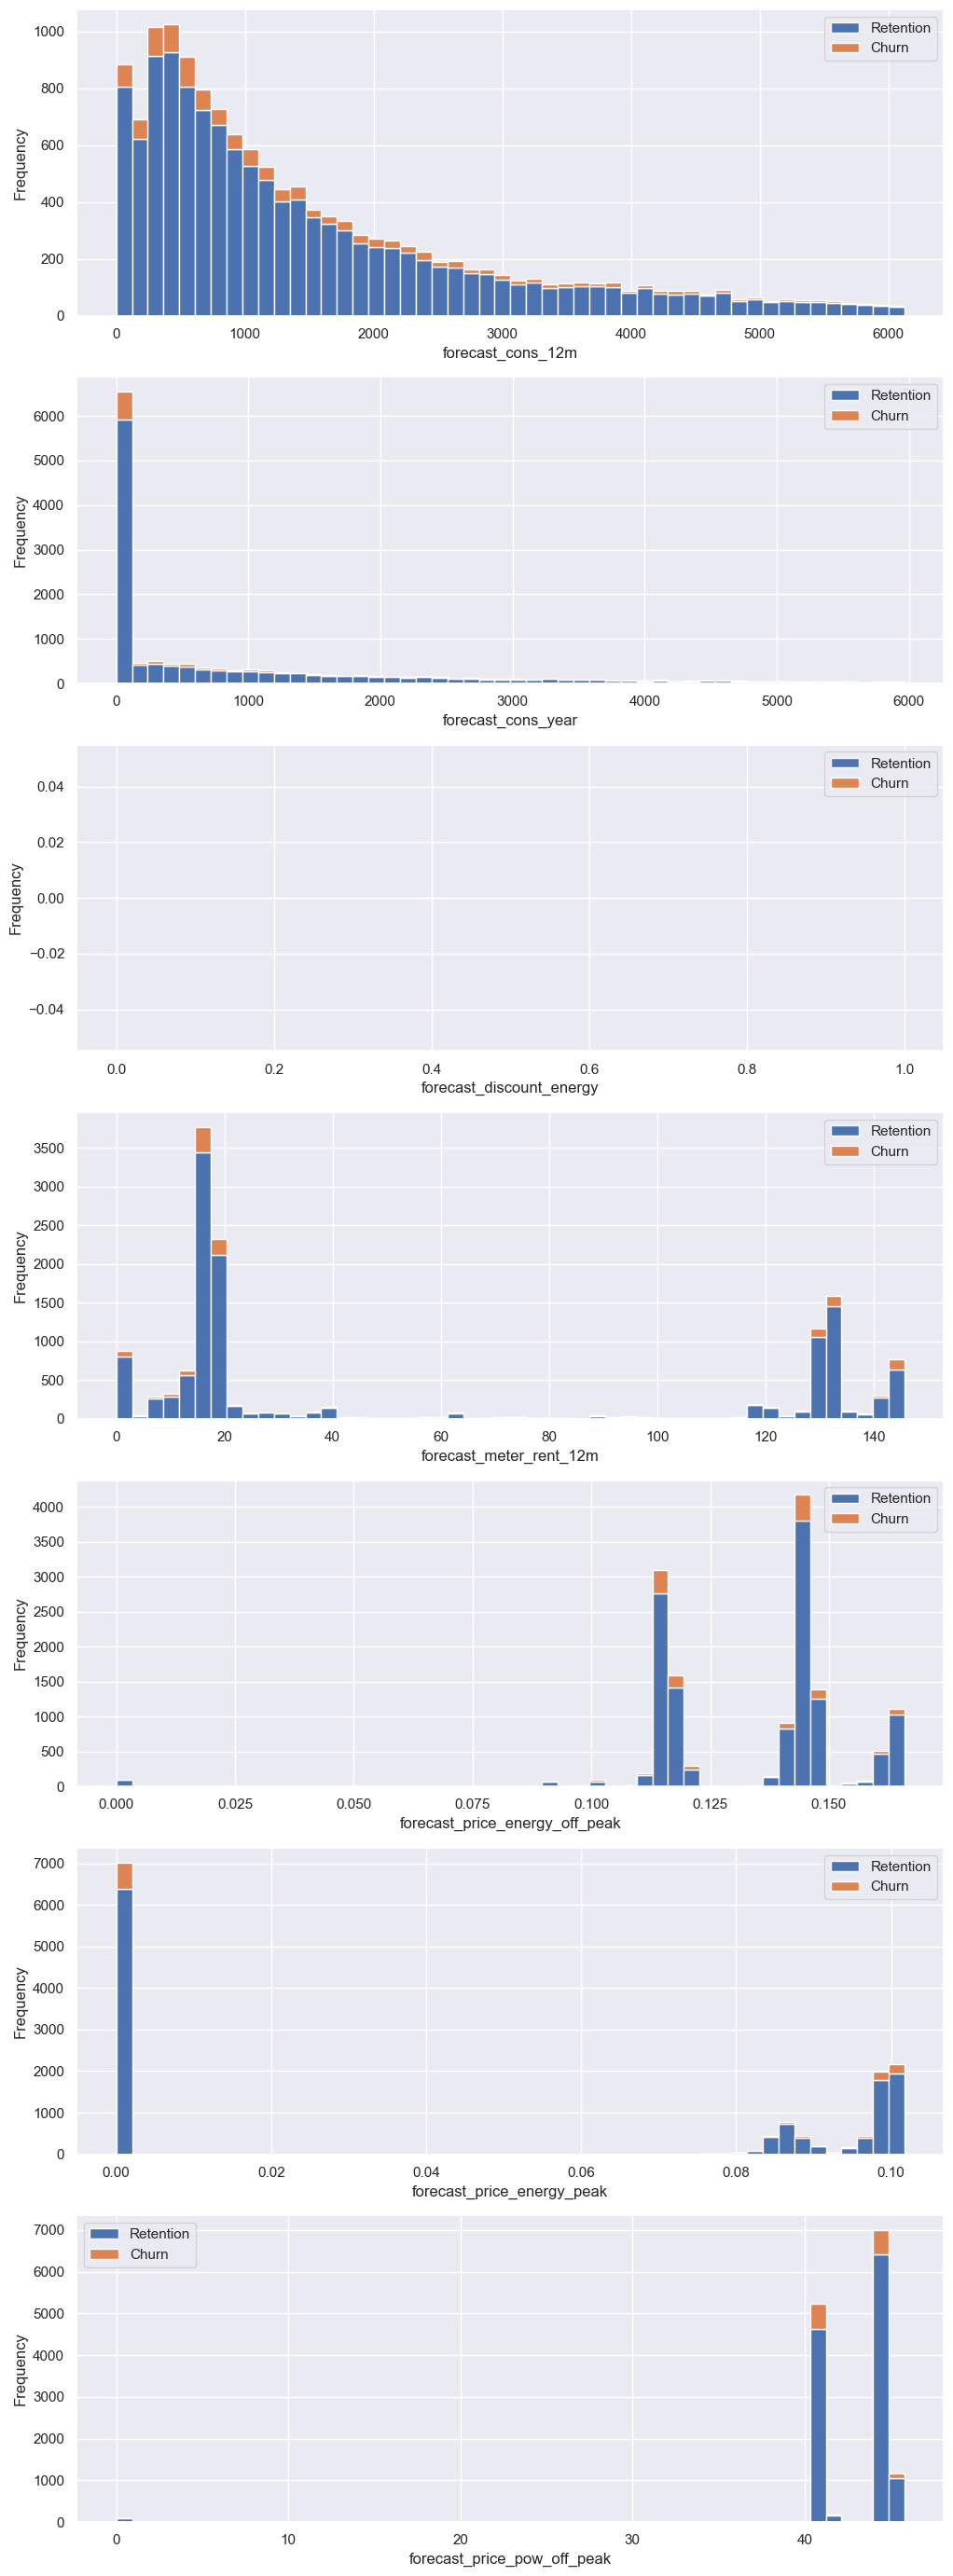

In [198]:
fig, axs = plt.subplots(nrows=len(FORECAST), figsize=(12, 5*len(FORECAST)))
for column,ax in zip(FORECAST, axs):
    plot_distribution(forecast_data, column, ax, c_quantile=0.95)

# cut down the outlier and filter for the value lower than 95th quantile, to have a clearer diagram to view

In [199]:
def plot_violinplot(dataframe, column, ax):
    sns.violinplot(x = dataframe[column], y = dataframe['churn'], orient = 'h', ax = ax)
    plt.xlabel(column)
    plt.ylabel('churn')
    plt.ticklabel_format(style='plain', axis='x')

['imp_cons',
 'margin_gross_pow_ele',
 'margin_net_pow_ele',
 'nb_prod_act',
 'net_margin',
 'num_years_antig',
 'pow_max']

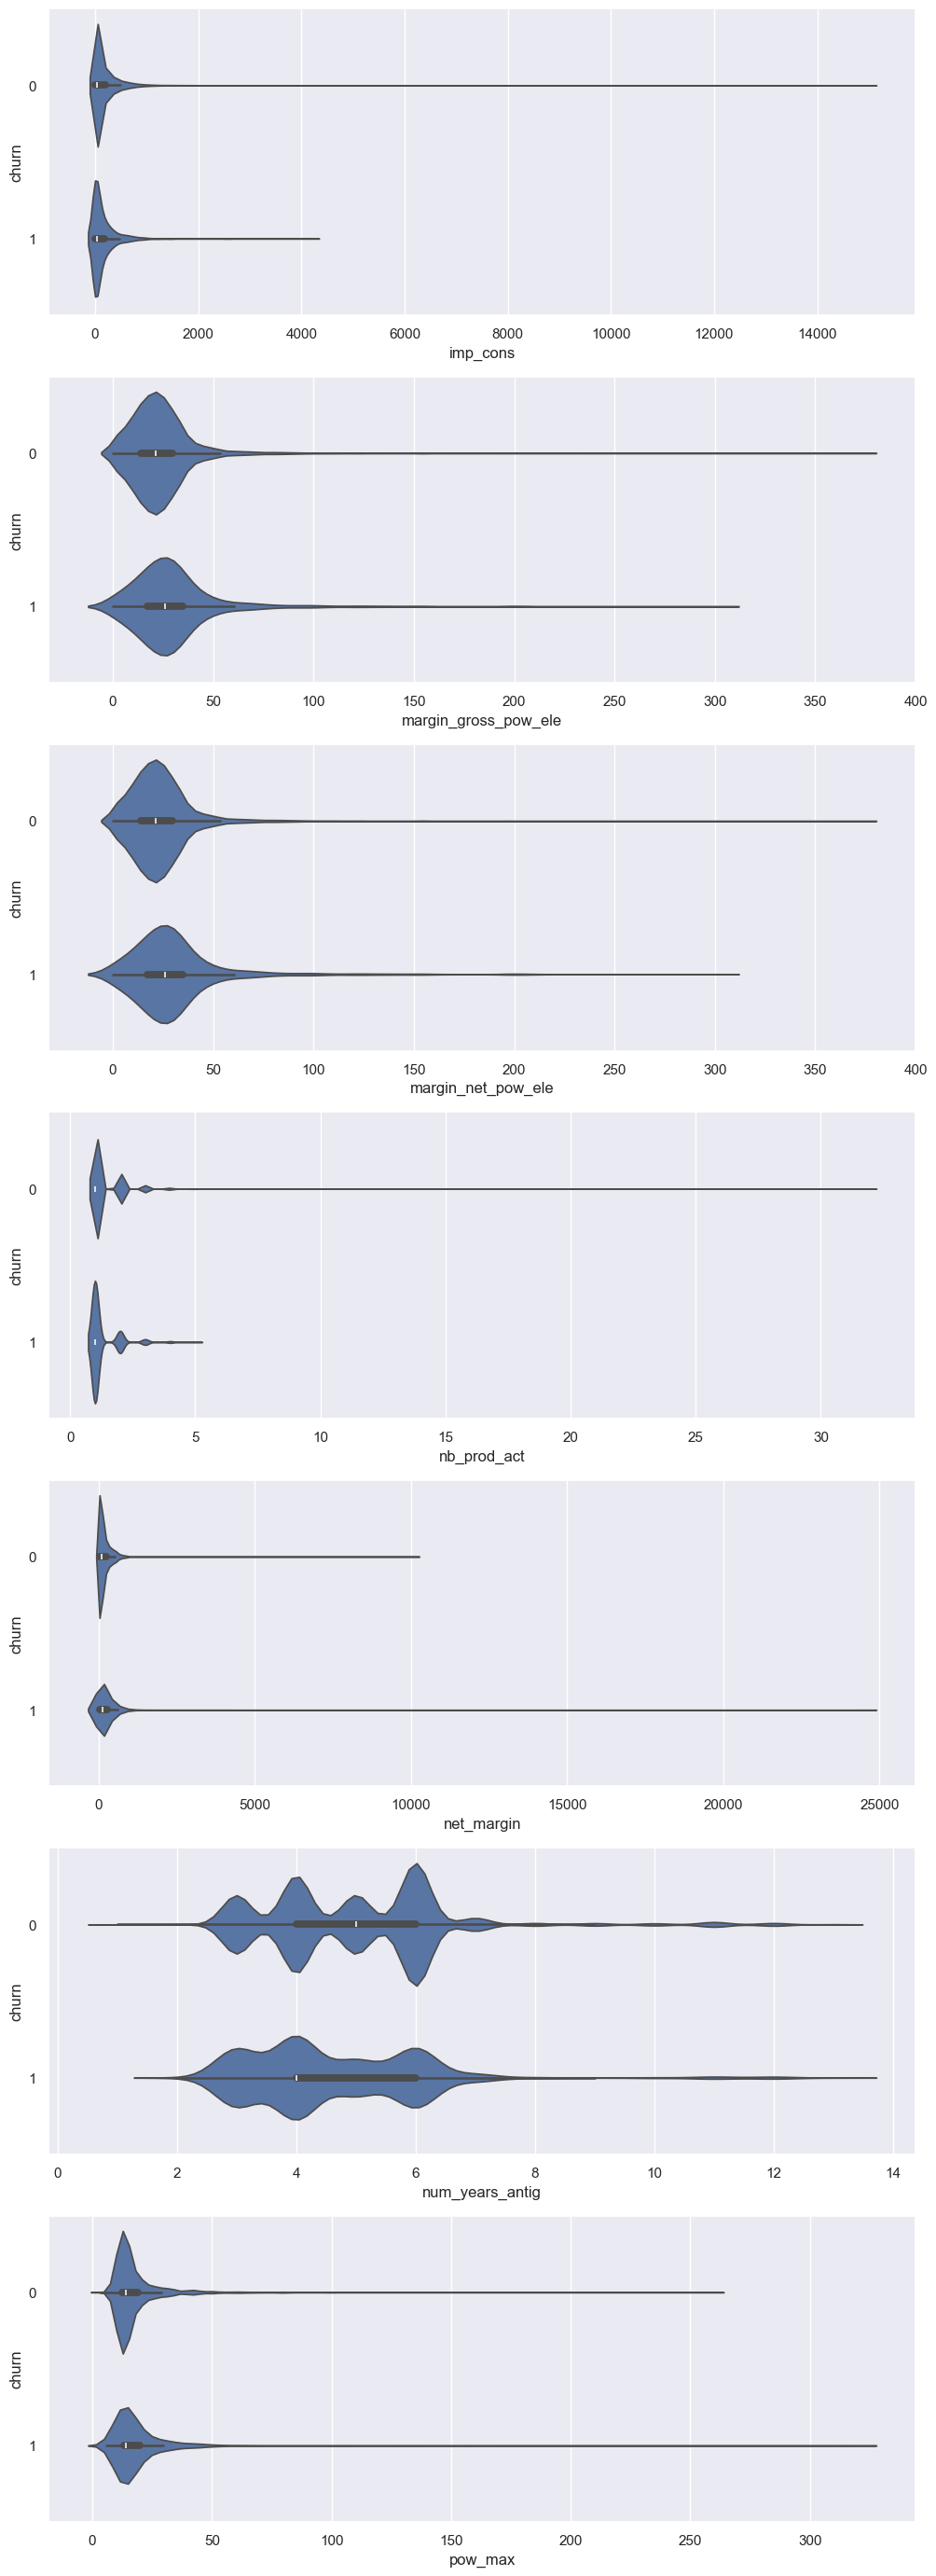

In [200]:
view_in_violinplot_data = client_df.columns[np.r_[17:23,24]].tolist()
display(view_in_violinplot_data)
fig, axs = plt.subplots(nrows=len(view_in_violinplot_data), figsize=(12, 5*len(view_in_violinplot_data)))

for column, ax in zip(view_in_violinplot_data, axs):
    plot_violinplot(client_df, column, ax)

From the diagram above, we notice that customer churn seem to be relative to "pow_max", "num_years_antig", "net_margin", "margin_net_pow_ele", "margin_gross_pow_ele".

considering the properties of those factor, "num_years_antig" and "pow_max" could be plotted with bar diagram, and the others we consider plot them with hist diagram

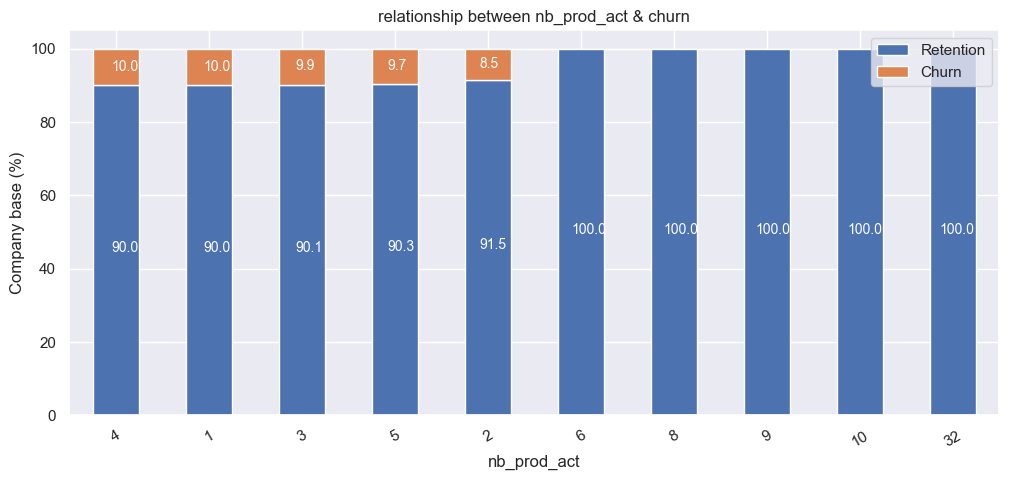

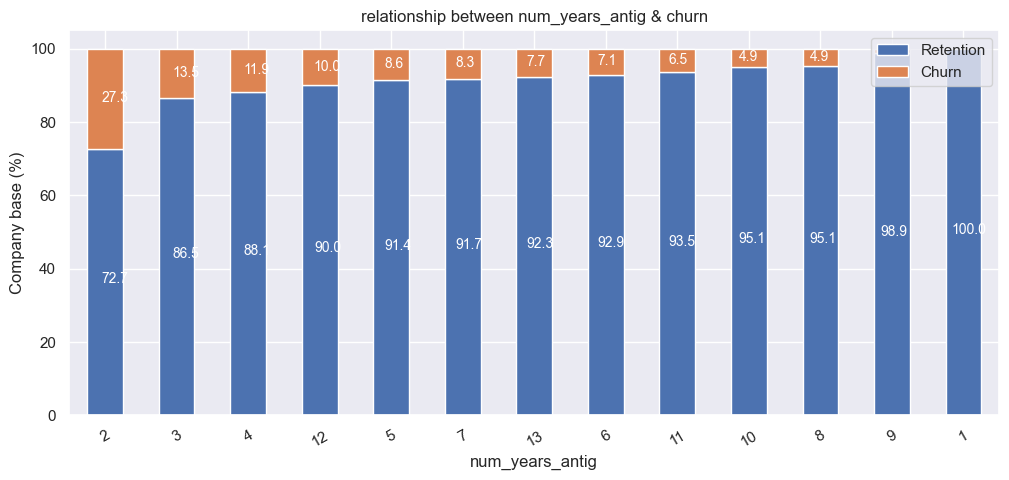

In [204]:
plot_data = client_df[['id', 'churn', 'nb_prod_act', 'num_years_antig']]

for column in plot_data.columns[2:]:
    plot_stacked_relationship_factor_and_churn(column)

In [202]:
def plot_hist(dataframe, column, ax, bins_size = 50):
    retention = dataframe[dataframe['churn']==0][column]
    churn = dataframe[dataframe['churn']==1][column]
    ax.hist(x = [retention, churn], bins = bins_size, stacked = True, label = ['retention', 'churn'])
    ax.set_xlabel(column)
    ax.set_ylabel('frequency')
    ax.legend()
    # sns.histplot(x = dataframe, kde = True, ax = ax, bins = bins_size)

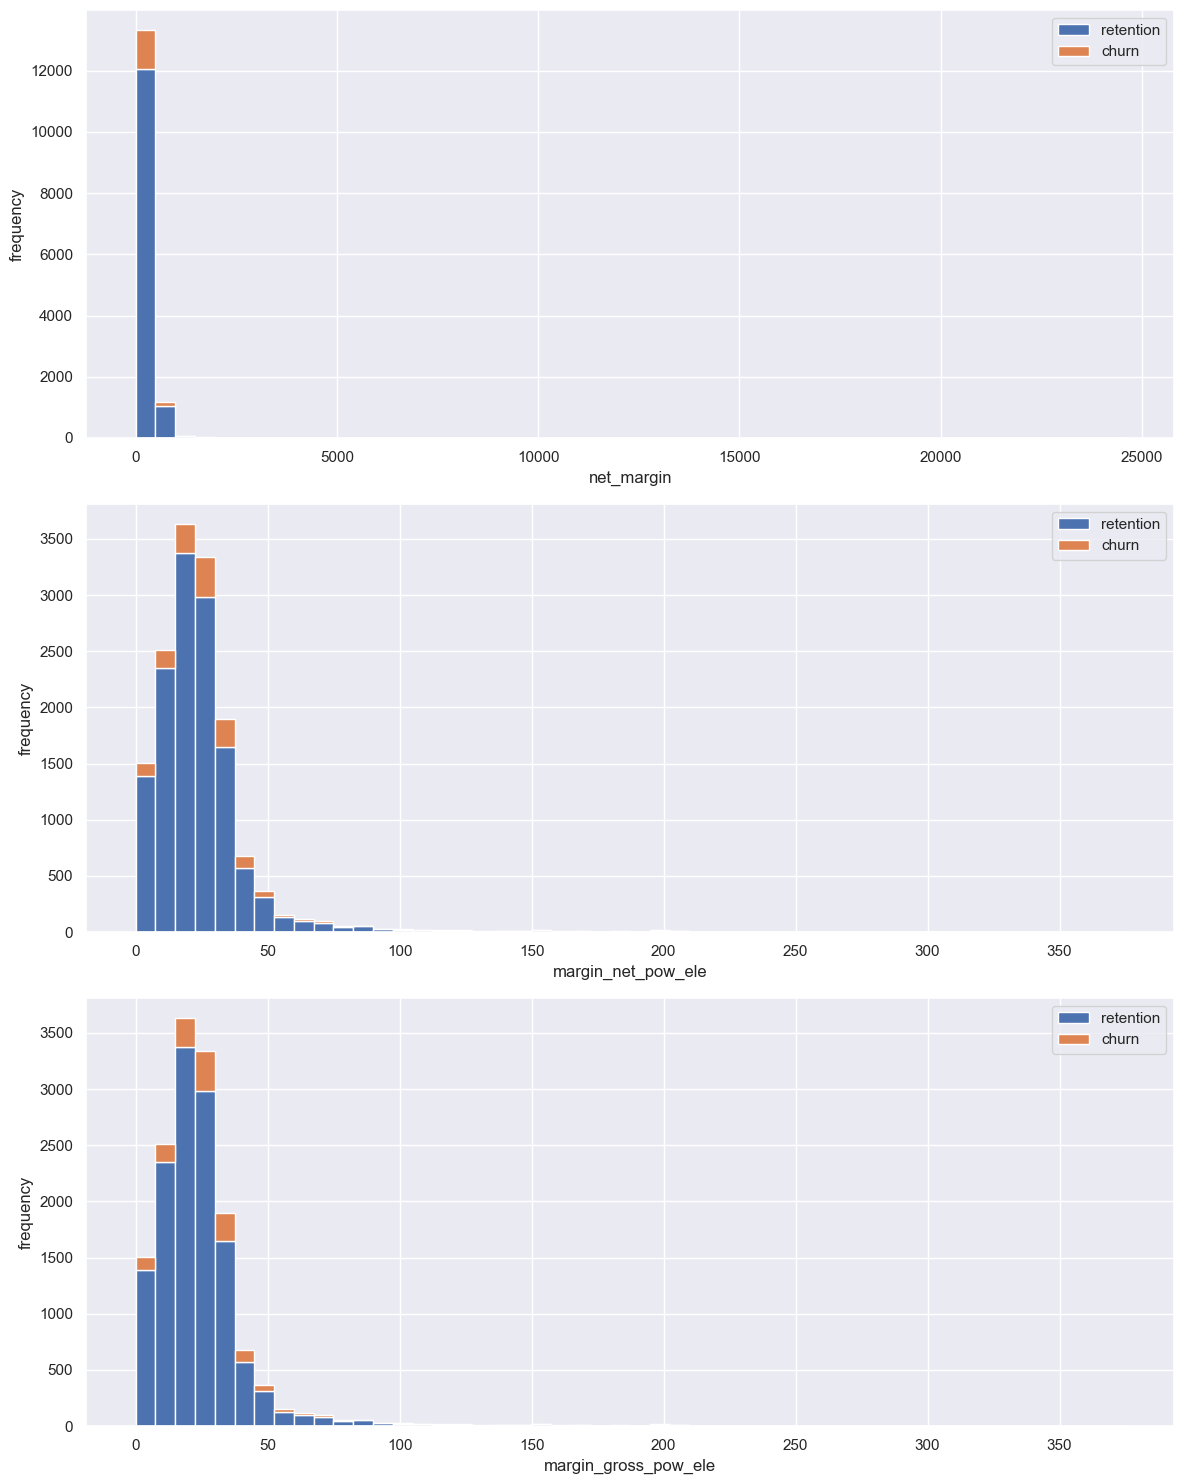

In [203]:
HIST_DATA = ["net_margin", "margin_net_pow_ele", "margin_gross_pow_ele"]
hist_data = client_df[["id", "churn"]+HIST_DATA]

fig, axs = plt.subplots(nrows = 3, figsize = (12,15))
for column,ax in zip(HIST_DATA, axs):
    plot_hist(hist_data, column, ax)
plt.tight_layout()

In [222]:
price_df['price_date'] = pd.to_datetime(price_df['price_date'], format='%Y-%m-%d')
price_column = price_df.columns[2:]

monthly_price_df = price_df.groupby(['price_date'])[price_column].agg(['mean', 'std', 'max', 'min'])
monthly_price_df

# monthly_price_df.plot()

price_off_peak_var                          price_peak_var  \
                         mean       std       max  min           mean   
price_date                                                              
2015-01-01           0.142568  0.022847  0.280700  0.0       0.054950   
2015-02-01           0.142767  0.023403  0.280700  0.0       0.055053   
2015-03-01           0.143104  0.023777  0.280700  0.0       0.055118   
2015-04-01           0.143259  0.024187  0.280700  0.0       0.056035   
2015-05-01           0.143534  0.024376  0.280700  0.0       0.055359   
2015-06-01           0.143731  0.024475  0.280700  0.0       0.055255   
2015-07-01           0.143683  0.024727  0.280700  0.0       0.055369   
2015-08-01           0.137933  0.025684  0.276238  0.0       0.053605   
2015-09-01           0.137933  0.026164  0.276238  0.0       0.053532   
2015-10-01           0.137899  0.026314  0.276238  0.0       0.053713   
2015-11-01           0.137909  0.026221  0.276238  0.0       0.053620   
2015-12-01           0.138011  0.026221  0.276238  0.0       0.053957   

                                    price_mid_peak_var            ...  \
                 std       max  min               mean       std  ...   
price_date                                                        ...   
2015-01-01  0.050329  0.229298  0.0           0.030333  0.035847  ...   
2015-02-01  0.050366  0.196782  0.0           0.030367  0.035920  ...   
2015-03-01  0.050482  0.229788  0.0           0.030396  0.036048  ...   
2015-04-01  0.050345  0.196782  0.0           0.030492  0.036186  ...   
2015-05-01  0.050531  0.196782  0.0           0.030393  0.036212  ...   
2015-06-01  0.050453  0.196782  0.0           0.029902  0.036171  ...   
2015-07-01  0.050699  0.196782  0.0           0.030636  0.036399  ...   
2015-08-01  0.049076  0.196029  0.0           0.030717  0.036459  ...   
2015-09-01  0.049134  0.196029  0.0           0.030606  0.036528  ...   
2015-10-01  0.049144  0.196029  0.0           0.030641  0.036573  ...   
2015-11-01  0.049225  0.196029  0.0           0.030737  0.036607  ...   
2015-12-01  0.049190  0.196029  0.0           0.030732  0.036617  ...   

           price_off_peak_fix      price_peak_fix                             \
                          max  min           mean        std        max  min   
price_date                                                                     
2015-01-01           59.44471  0.0      10.692921  12.833548  36.490692  0.0   
2015-02-01           59.44471  0.0      10.673719  12.825598  36.490692  0.0   
2015-03-01           59.44471  0.0      10.644489  12.823917  36.490692  0.0   
2015-04-01           59.44471  0.0      10.647277  12.837710  36.490692  0.0   
2015-05-01           59.44471  0.0      10.602453  12.837224  36.490692  0.0   
2015-06-01           59.44471  0.0      10.415769  12.800515  36.490692  0.0   
2015-07-01           59.44471  0.0      10.642236  12.845637  36.490692  0.0   
2015-08-01           59.44471  0.0      10.661678  12.854459  36.490692  0.0   
2015-09-01           59.44471  0.0      10.602979  12.852112  36.490692  0.0   
2015-10-01           59.44471  0.0      10.605431  12.854595  36.490692  0.0   
2015-11-01           59.44471  0.0      10.641489  12.867115  36.490689  0.0   
2015-12-01           59.44471  0.0      10.644109  12.872326  36.490689  0.0   

           price_mid_peak_fix                            
                         mean       std        max  min  
price_date                                               
2015-01-01           6.455861  7.771008  16.791555  0.0  
2015-02-01           6.449016  7.770768  16.791555  0.0  
2015-03-01           6.430121  7.769876  16.791555  0.0  
2015-04-01           6.423156  7.768547  16.791555  0.0  
2015-05-01           6.390806  7.763079  16.791555  0.0  
2015-06-01           6.281304  7.744157  16.791555  0.0  
2015-07-01           6.421464  7.775756  16.791555  0.0  
2015-08-01           6.431518  7.77920

Text(0, 0.5, 'std')

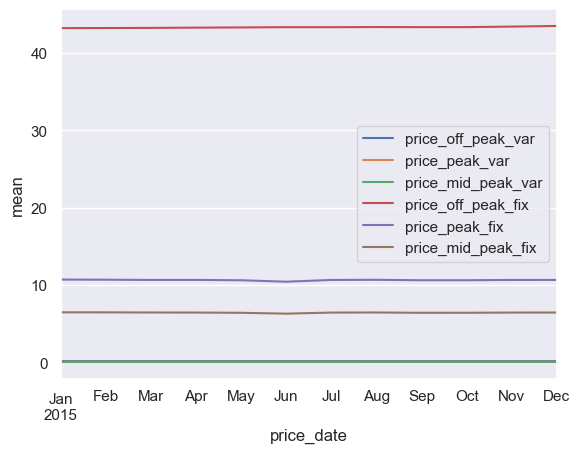

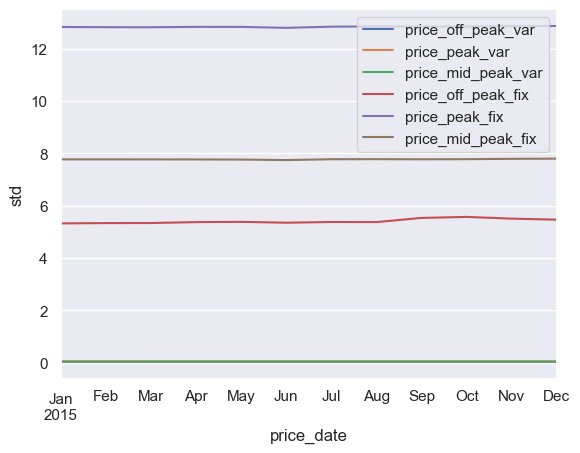

In [231]:
mean_df = monthly_price_df.xs('mean', axis = 1, level = 1)
std_df = monthly_price_df.xs('std', axis =1 , level = 1)
ax1 = mean_df.plot()
ax1.set_ylabel('mean')
ax2 = std_df.plot()
ax2.set_ylabel('std')